In [2]:
%load_ext autoreload
%autoreload 2

import numpy as np
import matplotlib.pyplot as plt
from lasso_model import fit_lasso, predict_lasso

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [3]:
rng = np.random.default_rng(seed=42)
n_samples = 100
n_features = 3 

X = rng.standard_normal((n_samples, n_features))

# Variable 1 est très forte (3.5), Variable 2 modérée (-1.5), Variable 3 est inutile (0.0)
true_intercept = 2.0
true_beta = np.array([3.5, -1.5, 0.0])

Y = true_intercept + (X @ true_beta) + rng.standard_normal(n_samples) * 0.5

In [4]:
lam = 0.1  # Force de la pénalité L1

intercept_calcule, beta_calcule = fit_lasso(X, Y, lam)

print("="*50)
print("--- COMPARAISON DES RÉSULTATS ---")
print(f"Vrai Intercept : {true_intercept}  | Calculé : {round(intercept_calcule, 3)}")
print(f"Vrais Betas    : {true_beta}")
print(f"Betas LASSO    : {np.round(beta_calcule, 3)}")
print("="*50)

--- COMPARAISON DES RÉSULTATS ---
Vrai Intercept : 2.0  | Calculé : 2.049
Vrais Betas    : [ 3.5 -1.5  0. ]
Betas LASSO    : [ 3.373 -1.371  0.   ]


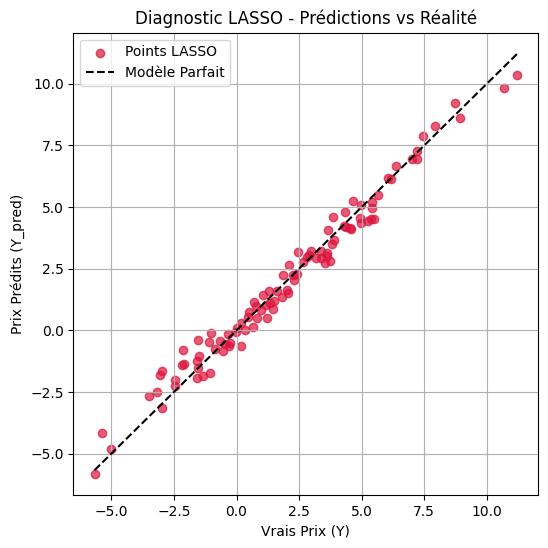

In [5]:
Y_pred = predict_lasso(X, intercept_calcule, beta_calcule)

plt.figure(figsize=(6, 6))
plt.scatter(Y, Y_pred, color='crimson', alpha=0.7, label='Points LASSO')
plt.plot([Y.min(), Y.max()], [Y.min(), Y.max()], 'k--', label='Modèle Parfait')
plt.title("Diagnostic LASSO - Prédictions vs Réalité")
plt.xlabel("Vrais Prix (Y)")
plt.ylabel("Prix Prédits (Y_pred)")
plt.legend()
plt.grid(True)
plt.show()

In [6]:
"""
A retenir
""" 

# 1. La force du LASSO en Finance : La Sélection de Variables
# Le concept de Sparsité :
# --> Contrairement à la régression Ridge qui réduit la valeur des coefficients sans jamais les annuler, la pénalité L_1 du LASSO génère de la sparsité 
# --> des poids exactement égaux à 0.0 
# --> Mathématiquement, la zone de contrainte du LASSO possède des "coins" pointus sur les axes, augmentant la probabilité géométrique que la solution touche un axe.

# Utilité Quant : C'est un outil formidable pour le *Feature Selection*. 
# --> Si un modèle contient 50 signaux alternatifs, le LASSO permet d'éliminer automatiquement les signaux redondants ou simples bruits de marché pour ne garder que les facteurs ayant une vraie valeur prédictive.


# 2. Algorithme de Descente par Coordonnées vs Équation Normale
# Pas de solution analytique
# --> La fonction valeur absolue de la pénalité L_1 n'est pas dérivable en zéro. 
# --> Impossible de poser une équation normale comme pour l'OLS ou Ridge.

# Alternative robuste : On utilise la Descente par Coordonnées. 
# --> L'algorithme optimise le modèle une seule variable à la fois en fixant toutes les autres. 
# --> Utilisation de l'opérateur de seuillage doux (`soft thresholding`) permet de décider de manière itérative si la variable mérite d'être conservée ou mise à zéro.

'\nA retenir\n'